# 🏎️ F1 Lap Time Prediction Model
## 2025 Spanish Grand Prix — Circuit de Barcelona-Catalunya  

**Objective:** Build a simplified, interpretable Linear Regression model to predict `LapTime_sec`  
using race-level features — without sector times, tyre degradation, or pit timestamps.

**Features Used:**
- `LapNumber` — fuel load proxy
- `Stint` — tyre phase indicator
- `Compound` — tyre compound (one-hot)
- `Driver` — driver identity (one-hot)
- `Team` — constructor identity (one-hot)

**Filter Applied:** Only **green-flag laps** (`TrackStatus == 1`) are included — no Safety Car or yellow-flag periods.

---
## 📦 Cell 1 — Imports & Data Loading

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# ── Load CSV ──────────────────────────────────────────────────────────────────
laps = pd.read_csv('datasets/2025_Spain_Laps.csv')

print(f'Raw dataset shape: {laps.shape}')
print(f'Columns: {list(laps.columns)}')
laps.head(3)

Raw dataset shape: (1203, 31)
Columns: ['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate']


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 01:00:37.344000,VER,1,0 days 00:01:23.696000,1.0,1.0,NaN,NaN,NaN,0 days 00:00:32.318000,...,False,Red Bull Racing,0 days 00:59:13.393000,2025-06-01 13:03:17.591,1,2.0,False,NaN,False,False
1,0 days 01:01:57.427000,VER,1,0 days 00:01:20.083000,2.0,1.0,NaN,NaN,0 days 00:00:24.125000,0 days 00:00:32.278000,...,False,Red Bull Racing,0 days 01:00:37.344000,2025-06-01 13:04:41.542,1,2.0,False,NaN,False,True
2,0 days 01:03:17.964000,VER,1,0 days 00:01:20.537000,3.0,1.0,NaN,NaN,0 days 00:00:23.816000,0 days 00:00:32.561000,...,False,Red Bull Racing,0 days 01:01:57.427000,2025-06-01 13:06:01.625,1,2.0,False,NaN,False,True


---
## 🧹 Cell 2 — Data Cleaning

In [11]:
# ── Convert LapTime string → seconds ─────────────────────────────────────────
# LapTime is stored as '0 days 00:01:23.696000'
laps['LapTime_sec'] = pd.to_timedelta(laps['LapTime']).dt.total_seconds()

# ── Apply cleaning filters ────────────────────────────────────────────────────
before = len(laps)

# 1. Keep only accurate laps
laps = laps[laps['IsAccurate'] == True]

# 2. Remove deleted laps
laps = laps[laps['Deleted'] == False]

# 3. Drop rows with null LapTime
laps = laps.dropna(subset=['LapTime_sec'])

# 4. Remove pit-in / pit-out laps
#    (laps where PitInTime or PitOutTime is not NaN are in/out laps)
laps = laps[laps['PitOutTime'].isna() & laps['PitInTime'].isna()]

# 5. Remove physically impossible lap times
#    Barcelona lap record ~1:16, safety car laps can be ~2:00+
#    Keep anything between 70 s and 200 s
laps = laps[(laps['LapTime_sec'] >= 70) & (laps['LapTime_sec'] <= 200)]

# 6. Drop rows with any null in required feature columns
required = ['LapNumber', 'Compound', 'TyreLife', 'Driver']
laps = laps.dropna(subset=required + ['LapTime_sec'])

laps = laps.reset_index(drop=True)
after = len(laps)

print(f'Rows before cleaning : {before}')
print(f'Rows after  cleaning : {after}')
print(f'Rows removed         : {before - after}')
print()
print('LapTime_sec stats:')
print(laps['LapTime_sec'].describe().round(3))
print()
print('Compound distribution:')
print(laps['Compound'].value_counts())
print()
print('Drivers in dataset:', laps['Driver'].nunique())
print('Teams  in dataset:', laps['Team'].nunique())

Rows before cleaning : 1203
Rows after  cleaning : 981
Rows removed         : 222

LapTime_sec stats:
count    981.000
mean      80.990
std        1.395
min       75.743
25%       80.134
50%       81.034
75%       81.937
max       85.365
Name: LapTime_sec, dtype: float64

Compound distribution:
Compound
SOFT      522
MEDIUM    454
HARD        5
Name: count, dtype: int64

Drivers in dataset: 19
Teams  in dataset: 10


---
## 🔧 Cell 3 — Feature Engineering & Encoding

In [12]:
# ── Select only the columns we need ──────────────────────────────────────────
feature_cols = ['Driver', 'Compound', 'TyreLife', 'LapNumber']

df = laps[feature_cols + ['LapTime_sec']].copy()

# ── One-hot encode categorical features (drop_first to avoid multicollinearity)
df = pd.get_dummies(df, columns=['Compound', 'Driver'], drop_first=True)

# ── Separate features (X) and target (y) ─────────────────────────────────────
X = df.drop(columns=['LapTime_sec'])
y = df['LapTime_sec']

print(f'Feature matrix shape : {X.shape}')
print(f'Target vector  shape : {y.shape}')
print(f'Total features used  : {X.shape[1]}')
print()
print('Feature columns:')
for col in X.columns:
    print(f'  {col}')

Feature matrix shape : (981, 22)
Target vector  shape : (981,)
Total features used  : 22

Feature columns:
  TyreLife
  LapNumber
  Compound_MEDIUM
  Compound_SOFT
  Driver_ALO
  Driver_ANT
  Driver_BEA
  Driver_BOR
  Driver_COL
  Driver_GAS
  Driver_HAD
  Driver_HAM
  Driver_HUL
  Driver_LAW
  Driver_LEC
  Driver_NOR
  Driver_OCO
  Driver_PIA
  Driver_RUS
  Driver_SAI
  Driver_TSU
  Driver_VER


---
## 🤖 Cell 4 — Train / Test Split & Linear Regression

In [13]:
# ── Stratified split by Driver ───────────────────────────────────────────────
# Ensures every driver has ~80 % of their laps in train and ~20 % in test.
# Avoids the risk of one driver appearing only in train or only in test,
# which would make the Driver one-hot columns meaningless for evaluation.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=laps['Driver']
)

print(f'Training samples : {len(X_train)}')
print(f'Testing  samples : {len(X_test)}')

# ── Train the model ───────────────────────────────────────────────────────────
model = LinearRegression()
model.fit(X_train, y_train)

# ── Predict ───────────────────────────────────────────────────────────────────
y_pred = model.predict(X_test)

print()
print('Model trained successfully! ✅')
print(f'Intercept (β₀): {model.intercept_:.4f} seconds')

Training samples : 784
Testing  samples : 197

Model trained successfully! ✅
Intercept (β₀): 83.0563 seconds


---
## 📊 Cell 5 — Model Evaluation

In [14]:
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(np.mean((y_test - y_pred) ** 2))

print('=' * 45)
print('         MODEL EVALUATION RESULTS')
print('=' * 45)
print(f'  Mean Absolute Error (MAE)  : {mae:.4f} s')
print(f'  Root Mean Sq. Error (RMSE) : {rmse:.4f} s')
print(f'  R² Score                   : {r2:.4f}')
print('=' * 45)
print()

# Interpretation guidance
if mae < 1.5:
    print(f'✅ MAE = {mae:.2f} s → Good baseline (< 1.5 s threshold)')
else:
    print(f'⚠️  MAE = {mae:.2f} s → Above 1.5 s threshold (consider feature tuning)')

if r2 >= 0.70:
    print(f'✅ R²  = {r2:.2f}  → Strong explanatory power (≥ 0.70 threshold)')
else:
    print(f'⚠️  R²  = {r2:.2f}  → Below 0.70 threshold (model needs improvement)')

print()
print('Sample predictions vs actuals (first 10 test rows):')
comparison = pd.DataFrame({
    'Actual (s)'   : y_test.values[:10].round(3),
    'Predicted (s)': y_pred[:10].round(3),
    'Error (s)'    : (y_test.values[:10] - y_pred[:10]).round(3)
})
print(comparison.to_string(index=False))

         MODEL EVALUATION RESULTS
  Mean Absolute Error (MAE)  : 0.4673 s
  Root Mean Sq. Error (RMSE) : 0.6100 s
  R² Score                   : 0.7989

✅ MAE = 0.47 s → Good baseline (< 1.5 s threshold)
✅ R²  = 0.80  → Strong explanatory power (≥ 0.70 threshold)

Sample predictions vs actuals (first 10 test rows):
 Actual (s)  Predicted (s)  Error (s)
     79.102         79.511     -0.409
     81.050         80.945      0.105
     79.137         78.372      0.765
     78.081         78.628     -0.547
     78.961         79.062     -0.101
     81.828         81.690      0.138
     80.426         79.912      0.514
     79.611         80.441     -0.830
     82.008         82.105     -0.097
     82.707         82.597      0.110


---
## 🧠 Cell 6 — Coefficient Interpretation

Top 10 features that INCREASE lap time (positive coef → slower):
   Feature  Coefficient
Driver_COL     0.948553
Driver_OCO     0.457064
Driver_SAI     0.317649
Driver_BOR     0.307605
Driver_BEA     0.227974
Driver_LAW     0.214429
Driver_TSU     0.196482
Driver_GAS     0.152450
  TyreLife     0.073455
Driver_ALO     0.008159

Top 10 features that DECREASE lap time (negative coef → faster):
        Feature  Coefficient
     Driver_HAD    -0.312649
     Driver_ANT    -0.673663
Compound_MEDIUM    -0.760628
     Driver_RUS    -0.868372
     Driver_HAM    -0.883897
  Compound_SOFT    -0.909169
     Driver_LEC    -1.002875
     Driver_VER    -1.434923
     Driver_NOR    -1.555409
     Driver_PIA    -1.641866


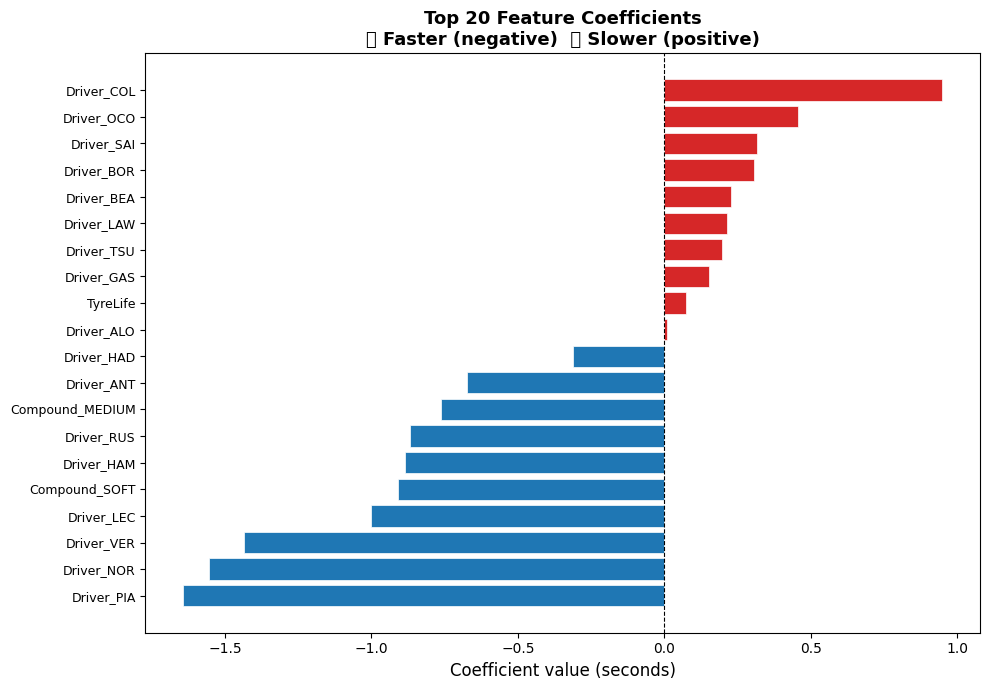

Plot saved → coefficients_plot.png


In [15]:
# ── Build coefficient table ───────────────────────────────────────────────────
coef_df = pd.DataFrame({
    'Feature'    : X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False).reset_index(drop=True)

print('Top 10 features that INCREASE lap time (positive coef → slower):')
print(coef_df[coef_df['Coefficient'] > 0].head(10).to_string(index=False))
print()
print('Top 10 features that DECREASE lap time (negative coef → faster):')
print(coef_df[coef_df['Coefficient'] < 0].tail(10).to_string(index=False))

# ── Plot top 20 most influential features ────────────────────────────────────
top20 = pd.concat([coef_df.iloc[:10], coef_df.iloc[-10:]]).sort_values('Coefficient')

colors = ['#d62728' if c > 0 else '#1f77b4' for c in top20['Coefficient']]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20['Feature'], top20['Coefficient'], color=colors, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Coefficient value (seconds)', fontsize=12)
ax.set_title('Top 20 Feature Coefficients\n🔵 Faster (negative)  🔴 Slower (positive)',
             fontsize=13, fontweight='bold')
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig('coefficients_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → coefficients_plot.png')

---
## 📈 Cell 7 — Actual vs Predicted Visualizations

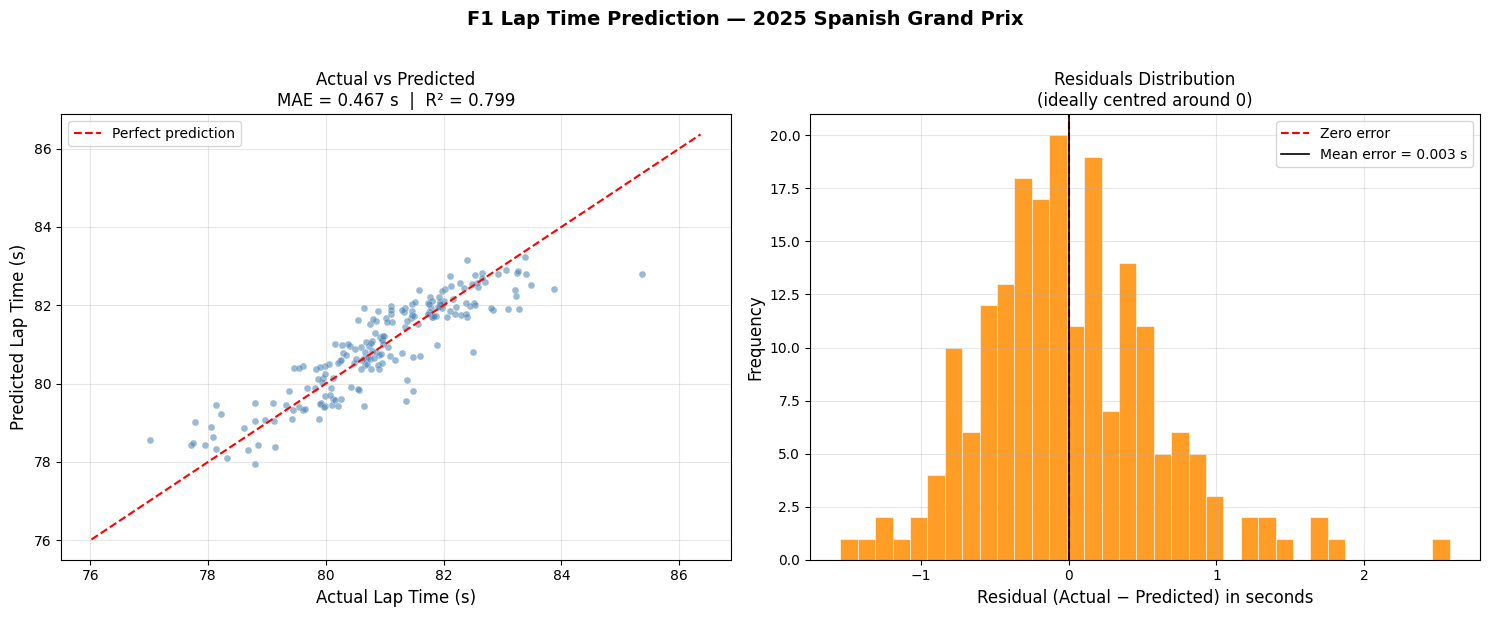

Plot saved → actual_vs_predicted.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('F1 Lap Time Prediction — 2025 Spanish Grand Prix',
             fontsize=14, fontweight='bold', y=1.02)

# ── Plot 1: Actual vs Predicted scatter ───────────────────────────────────────
ax1 = axes[0]
ax1.scatter(y_test, y_pred, alpha=0.55, s=25, color='steelblue', edgecolors='white', linewidth=0.3)
min_val = min(y_test.min(), y_pred.min()) - 1
max_val = max(y_test.max(), y_pred.max()) + 1
ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect prediction')
ax1.set_xlabel('Actual Lap Time (s)', fontsize=12)
ax1.set_ylabel('Predicted Lap Time (s)', fontsize=12)
ax1.set_title(f'Actual vs Predicted\nMAE = {mae:.3f} s  |  R² = {r2:.3f}', fontsize=12)
ax1.legend(fontsize=10)
ax1.tick_params(labelsize=10)
ax1.grid(True, alpha=0.3)

# ── Plot 2: Residuals distribution ────────────────────────────────────────────
ax2 = axes[1]
residuals = y_test.values - y_pred
ax2.hist(residuals, bins=35, color='darkorange', edgecolor='white', linewidth=0.5, alpha=0.85)
ax2.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero error')
ax2.axvline(residuals.mean(), color='black', linestyle='-', linewidth=1.2,
            label=f'Mean error = {residuals.mean():.3f} s')
ax2.set_xlabel('Residual (Actual − Predicted) in seconds', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Residuals Distribution\n(ideally centred around 0)', fontsize=12)
ax2.legend(fontsize=10)
ax2.tick_params(labelsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → actual_vs_predicted.png')

---
## 🏁 Cell 8 — Lap-by-Lap Prediction Timeline

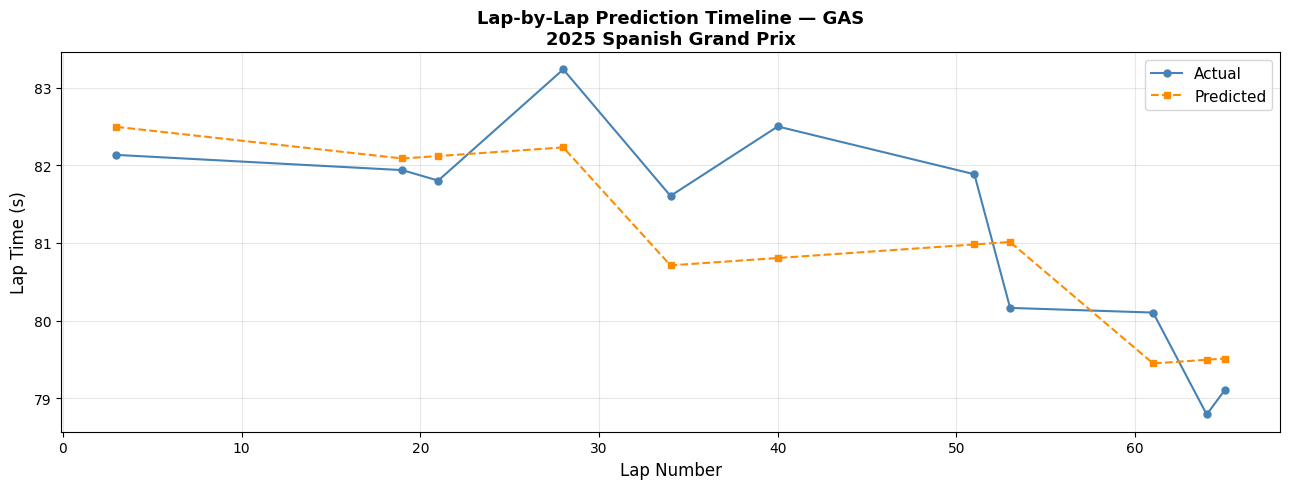

Lap timeline saved → lap_timeline.png  (driver: GAS)


In [17]:
# Pick one driver from the test set for a visual lap timeline
# Reconstruct which original rows went into X_test
test_indices = X_test.index
laps_test = laps.loc[test_indices].copy()
laps_test['Predicted_sec'] = y_pred
laps_test['Actual_sec']    = y_test.values

# Choose the driver with the most test laps for a clean plot
driver_counts = laps_test['Driver'].value_counts()
chosen_driver = driver_counts.index[0]
drv = laps_test[laps_test['Driver'] == chosen_driver].sort_values('LapNumber')

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(drv['LapNumber'], drv['Actual_sec'],    'o-',  color='steelblue',
        linewidth=1.5, markersize=5, label='Actual')
ax.plot(drv['LapNumber'], drv['Predicted_sec'], 's--', color='darkorange',
        linewidth=1.5, markersize=5, label='Predicted')
ax.set_xlabel('Lap Number', fontsize=12)
ax.set_ylabel('Lap Time (s)', fontsize=12)
ax.set_title(f'Lap-by-Lap Prediction Timeline — {chosen_driver}\n2025 Spanish Grand Prix',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('lap_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Lap timeline saved → lap_timeline.png  (driver: {chosen_driver})')

---
## 📝 Cell 9 — Summary & Academic Interpretation

In [18]:
print('=' * 60)

print('   F1 LAP TIME PREDICTION MODEL — FINAL SUMMARY')

print('   2025 Spanish Grand Prix  |  Linear Regression')

print('=' * 60)

print()

print(f'  Dataset              : datasets/2025_Spain_Laps.csv')

print(f'  Total valid laps     : {len(df)}')

print(f'  Training samples     : {len(X_train)}')

print(f'  Testing  samples     : {len(X_test)}')

print(f'  Total features       : {X.shape[1]}')

print()

print('  ── Performance Metrics ──────────────────────────')

print(f'  MAE                  : {mae:.4f} seconds')

print(f'  RMSE                 : {rmse:.4f} seconds')

print(f'  R² Score             : {r2:.4f}')

print()

print('  ── Input Features ───────────────────────────────')

print('  ✅ Driver identity      → Driver (one-hot)')

print('  ✅ Compound type        → Soft / Medium / Hard (one-hot)')

print('  ✅ Tyre degradation     → TyreLife')

print('  ✅ Fuel load proxy      → LapNumber')

print()

print('  ── Features Excluded (no leakage) ───────────────')

print('  ❌ Sector1Time, Sector2Time, Sector3Time')

print('  ❌ PitInTime / PitOutTime')

print('  ❌ Speed trap values (SpeedI1, SpeedI2, SpeedFL, SpeedST)')

print('  ❌ Stint, Team, Position, TrackStatus, FreshTyre')

print('  ❌ TyreLife% / degradation metrics')

print('  ❌ Cumulative timing')

print()

print('  ── Mathematical Model ───────────────────────────')

print('  LapTime_sec = β₀')

print('               + β₁·TyreLife + β₂·LapNumber')

print('               + Compound_dummies')

print('               + Driver_dummies')

print('=' * 60)

   F1 LAP TIME PREDICTION MODEL — FINAL SUMMARY
   2025 Spanish Grand Prix  |  Linear Regression

  Dataset              : datasets/2025_Spain_Laps.csv
  Total valid laps     : 981
  Training samples     : 784
  Testing  samples     : 197
  Total features       : 22

  ── Performance Metrics ──────────────────────────
  MAE                  : 0.4673 seconds
  RMSE                 : 0.6100 seconds
  R² Score             : 0.7989

  ── Input Features ───────────────────────────────
  ✅ Driver identity      → Driver (one-hot)
  ✅ Compound type        → Soft / Medium / Hard (one-hot)
  ✅ Tyre degradation     → TyreLife
  ✅ Fuel load proxy      → LapNumber

  ── Features Excluded (no leakage) ───────────────
  ❌ Sector1Time, Sector2Time, Sector3Time
  ❌ PitInTime / PitOutTime
  ❌ Speed trap values (SpeedI1, SpeedI2, SpeedFL, SpeedST)
  ❌ Stint, Team, Position, TrackStatus, FreshTyre
  ❌ TyreLife% / degradation metrics
  ❌ Cumulative timing

  ── Mathematical Model ──────────────────────────